LABORATORIO 2

In [69]:
# Importando librerias
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [86]:
# Extraendo los datos

data = pd.read_csv('bank-additional-full.csv', delimiter=';')

# Cuantificando los datos de varias columnas
data['job'] = data['job'].map({'admin.':1, 'blue-collar':2, 'entrepreneur':3, 'housemaid':4, 'management':5, 'retired':6, 'self-employed':7, 'services':8, 'student':9, 'technician':10, 'unemployed':11, 'unknown':12})
data['marital'] = data['marital'].map({'divorced':1, 'married':2, 'single':3, 'unknown':4})
data['education'] = data['education'].map({'basic.4y':1, 'basic.6y':2, 'basic.9y':3, 'high.school':4, 'illiterate':5, 'professional.course':6, 'university.degree':7, 'unknown':8 })
data['default'] = data['default'].map({'yes':1, 'no':2, 'unknown':3})
data['housing'] = data['housing'].map({'yes':1, 'no':2, 'unknown':3})
data['loan'] = data['loan'].map({'yes':1, 'no':2, 'unknown':3})
data['contact'] = data['contact'].map({'telephone':1, 'cellular':2})
data['month'] = data['month'].map({'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jul':6, 'jun':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12})
data['day_of_week'] = data['day_of_week'].map({'mon':1, 'tue':2, 'wed':3, 'thu':4, 'fri':5})
data['poutcome'] = data['poutcome'].map({'failure':1, 'nonexistent':2, 'success':3})
data['y'] = data['y'].map({'no':0, 'yes':1})

# Verificar que no exsitan filas con valores nulos
print(data.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [71]:
# Creando las matrices X y Y
x = data[["age","job","marital","education","default","housing","loan","contact",
          "month","day_of_week","duration","campaign","pdays","previous",
          "poutcome","emp.var.rate","cons.price.idx","cons.conf.idx","euribor3m","nr.employed"]]
y = data['y']

In [72]:
print(x)

       age  job  marital  education  default  housing  loan  contact  month  \
0       56    4        2          1        2        2     2        1      5   
1       57    8        2          4        3        2     2        1      5   
2       37    8        2          4        2        1     2        1      5   
3       40    1        2          2        2        2     2        1      5   
4       56    8        2          4        2        2     1        1      5   
...    ...  ...      ...        ...      ...      ...   ...      ...    ...   
41183   73    6        2          6        2        1     2        2     11   
41184   46    2        2          6        2        2     2        2     11   
41185   56    6        2          7        2        1     2        2     11   
41186   44   10        2          6        2        2     2        2     11   
41187   74    6        2          6        2        1     2        2     11   

       day_of_week  duration  campaign  pdays  prev

In [73]:
print(y)

0        0
1        0
2        0
3        0
4        0
        ..
41183    1
41184    0
41185    0
41186    1
41187    0
Name: y, Length: 41188, dtype: int64


FUNCION PARA NORMALIZAR LOS DATOS:

In [74]:
def normalizacion(x):
    x_norm = x.copy()
    miu = np.zeros(x.shape[1])
    sigma = np.zeros(x.shape[1])

    miu = np.mean(x , axis=0)
    sigma = np.std(x , axis=0)
    x_norm = (x - miu)/sigma
    
    return x_norm, miu, sigma



In [ ]:
# Normalizando los datos
x_norm, miu, sigma = normalizacion(x)

In [76]:
def sigmoid(z):

    z = np.array(z)
    g = np.array(z.shape)

    

    g = 1/(1 + np.exp(-z))

    return g

In [ ]:
# concatenando la columna de unos a x
m = y.shape[0]
x_vars = np.concat([np.ones((m,1)), x_norm], axis=1)
print(x_vars)

[[ 1.          1.53303429 -0.20157925 ...  0.88644656  0.71245988
   0.33167991]
 [ 1.          1.62899323  0.91122681 ...  0.88644656  0.71245988
   0.33167991]
 [ 1.         -0.29018564  0.91122681 ...  0.88644656  0.71245988
   0.33167991]
 ...
 [ 1.          1.53303429  0.35482378 ... -2.22495344 -1.49518647
  -2.8156966 ]
 [ 1.          0.38152696  1.46762984 ... -2.22495344 -1.49518647
  -2.8156966 ]
 [ 1.          3.26029527  0.35482378 ... -2.22495344 -1.49518647
  -2.8156966 ]]


FUNCION DE COSTO LOG-LOSS

In [78]:
def calCosto(x,y,theta):
    j = 0
    m = y.size

    h = sigmoid(x.dot(theta.T))
    
    j = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    
    return j 

DESCENSO POR EL GRADIENTE

In [79]:
def desGradiente(x, y, theta, alpha, num_iters):
    theta = theta.copy()
    J_history = []
    m = y.shape[0]


    for i in range(num_iters):
        h = sigmoid(x.dot(theta.T))
      
        theta = theta - (alpha / m) * (h - y).dot(x)
        J_history.append(calCosto(x,y,theta))

    return theta, J_history


In [ ]:
# Asignando valores para la funcion del descenso por el gradiente
alpha = 0.001
num_iters = 20000

theta = np.zeros(21)

theta, J_history = desGradiente(x_vars, y, theta, alpha, num_iters)

print('valores de theta:',theta)

valores de theta: [-2.16554657e+00  4.97180936e-02  2.23057486e-02  4.25875586e-02
  7.25263106e-02 -8.21390220e-02 -2.17746616e-04  9.01387325e-03
  1.33018189e-01  3.54945768e-02  1.57296708e-02  7.76440810e-01
 -2.83554166e-02 -1.79532269e-01  4.80354697e-02  1.58723898e-01
 -1.93702878e-01  9.99845097e-02  1.33717960e-01 -2.04991590e-01
 -3.17882183e-01]


GRAFICANDO LA FUNCION DE COSTO

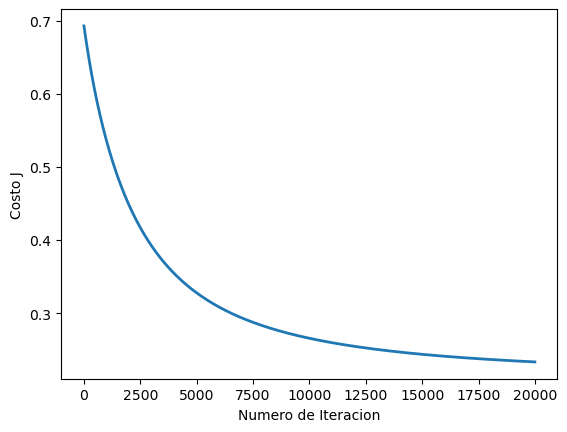

In [84]:
plt.plot(np.arange(len(J_history)), J_history , lw=2)
plt.xlabel("Numero de Iteracion")
plt.ylabel("Costo J")
plt.show()

REALIZANDO PREDICCIONES 

In [ ]:
x1 = np.array([55,2,2,2,3,1,1,1,6,5,500,1.1,900,0,1,1,193.994,-36.4,4.857,5191])
#Normalizando los datos
x2 = (x1 - miu) / sigma
pred1 = np.append(1 , x2)


y_inferida1 = np.dot(pred1, theta)
# Aplicando funcion sigmoide
z = sigmoid(y_inferida1)
print("adquiere el servicio ",z)


adquiere el servicio  0.9999996674541369
